## Import Required Libraries

The libraries below are used for data handling, numerical calculations, and visualisation.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Dataset Loading and Initial Audit

The original Online Retail dataset is loaded for the micro-level analysis.

A random seed of 42 is set so that the results are reproducible.

The initial audit checks:
- Dataset shape
- Data types
- Missing values
- Summary statistics

In [55]:
SEED = 42
np.random.seed(SEED)

# 1. Load the raw dataset
df = pd.read_csv(
    r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data.csv',
    encoding='ISO-8859-1'
)

print("=" * 60)
print("SECTION A - DATASET AUDIT")
print("=" * 60)
print(f"Original Shape: {df.shape}")

SECTION A - DATASET AUDIT
Original Shape: (541909, 8)


### Dataset Structure and Missing Values

The dataset structure is examined to identify the data types of each column and the number of missing values.

This helps us understand the data before performing any cleaning or preprocessing.

In [56]:
print("\nData Types and Dataset Information:")
df.info()

print("\nMissing Value Counts:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe().T)


Data Types and Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Value Counts:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Summary Statistics:
               count          mean          std       min       25%       50%  \
Quantity    541909.0      9.552250   218.08115

## Initial Data Cleaning

Invalid transactions are removed before further analysis.

Rows with:
- Zero or negative quantity
- Zero or negative unit price

are excluded.

This removes cancelled/returned transactions and invalid pricing records from the modelling dataset.

In [57]:
# Remove cancellations, returns, and invalid pricing records
df_clean = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Rows after cleaning: 530104
Rows removed: 11805


## Date Formatting

The `InvoiceDate` column is converted from text format to datetime format.

This allows us to extract useful date and time information later during feature engineering.

In [58]:
df_clean['InvoiceDate'] = pd.to_datetime(
    df_clean['InvoiceDate'],
    errors='coerce'
)

print("InvoiceDate converted to datetime format.")
print(df_clean['InvoiceDate'].head())

InvoiceDate converted to datetime format.
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


## EDA Visualizations

The following visualizations are used to understand the distribution of the target variable, relationships among numerical variables, and differences in Unit Price across countries.

Since the transaction-level dataset contains a large number of observations, a sample is used for the scatter plot to make the visualization easier to interpret.

### Target Distribution

The histogram shows the distribution of `UnitPrice`. A logarithmic scale is used because Unit Price is highly skewed, with many low-priced transactions and relatively fewer high-priced transactions.

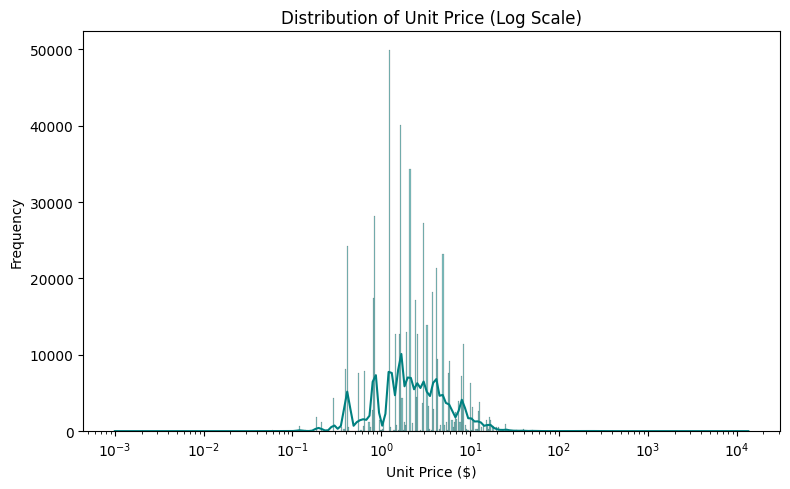

In [59]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['UnitPrice'],
    kde=True,
    color='teal',
    log_scale=True
)

plt.title("Distribution of Unit Price (Log Scale)")
plt.xlabel("Unit Price ($)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Correlation Heatmap

The correlation heatmap shows the linear relationships among the numerical variables in the cleaned dataset. It helps identify variables that have stronger relationships with the target variable.

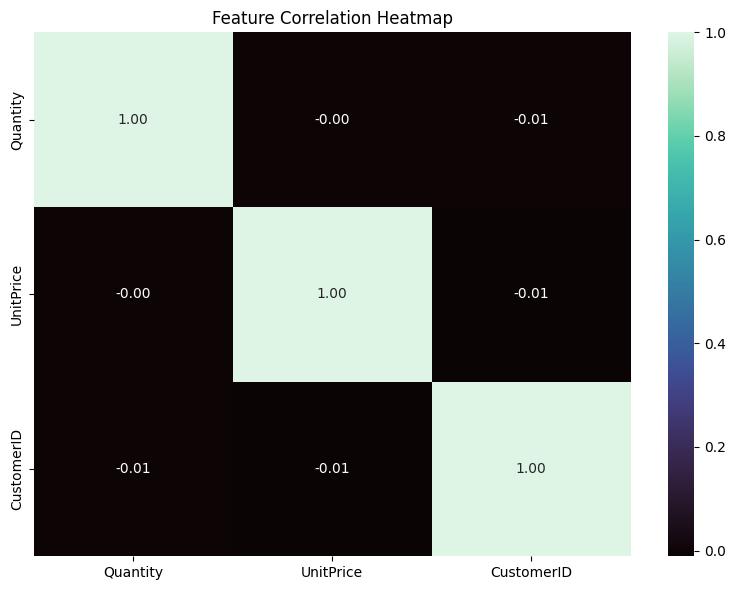

In [60]:
numeric_eda_cols = df_clean.select_dtypes(
    include=[np.number]
).columns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_clean[numeric_eda_cols].corr(),
    annot=True,
    cmap='mako',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

### Quantity vs. Unit Price

The scatter plot examines the relationship between `Quantity` and `UnitPrice`. Since the dataset contains a large number of transactions, a sample of up to 10,000 observations is used to improve readability.

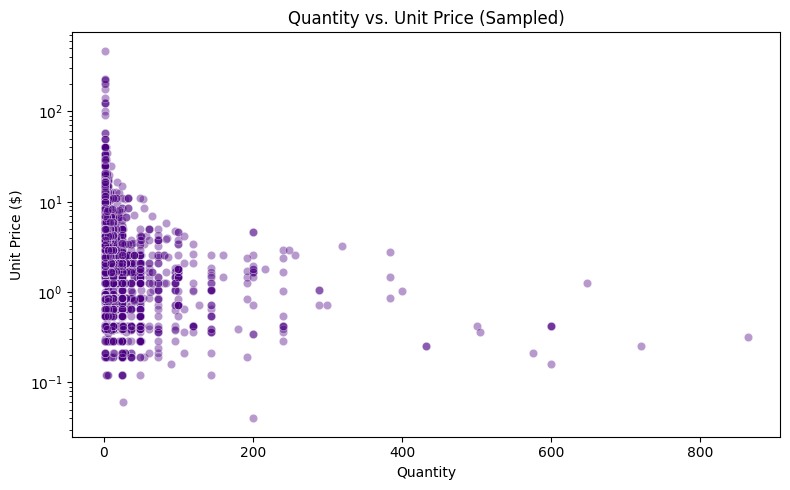

In [61]:
eda_sample = df_clean.sample(
    min(10000, len(df_clean)),
    random_state=SEED
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_sample,
    x='Quantity',
    y='UnitPrice',
    color='indigo',
    alpha=0.4
)

plt.title("Quantity vs. Unit Price (Sampled)")
plt.xlabel("Quantity")
plt.ylabel("Unit Price ($)")
plt.yscale('log')

plt.tight_layout()
plt.show()

### Unit Price Distribution Across Countries

The boxplot compares the distribution of `UnitPrice` across the six countries with the highest number of transactions. This helps identify differences in pricing patterns between major markets.

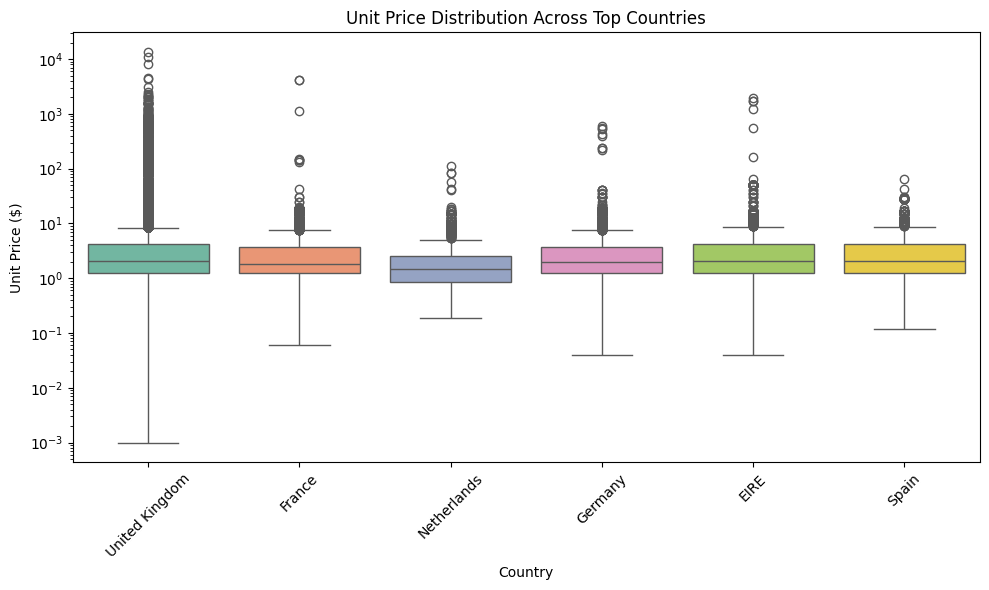

In [62]:
top_countries = (
    df_clean['Country']
    .value_counts()
    .head(6)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean[df_clean['Country'].isin(top_countries)],
    x='Country',
    y='UnitPrice',
    hue='Country',
    legend=False,
    palette='Set2'
)

plt.title("Unit Price Distribution Across Top Countries")
plt.xlabel("Country")
plt.ylabel("Unit Price ($)")
plt.xticks(rotation=45)
plt.yscale('log')

plt.tight_layout()
plt.show()

### Numerical Feature Distributions

The distributions of the numerical variables are examined to understand their ranges, skewness, and the presence of extreme values.

Histograms with KDE curves are used to visualize the overall shape of each numerical feature.

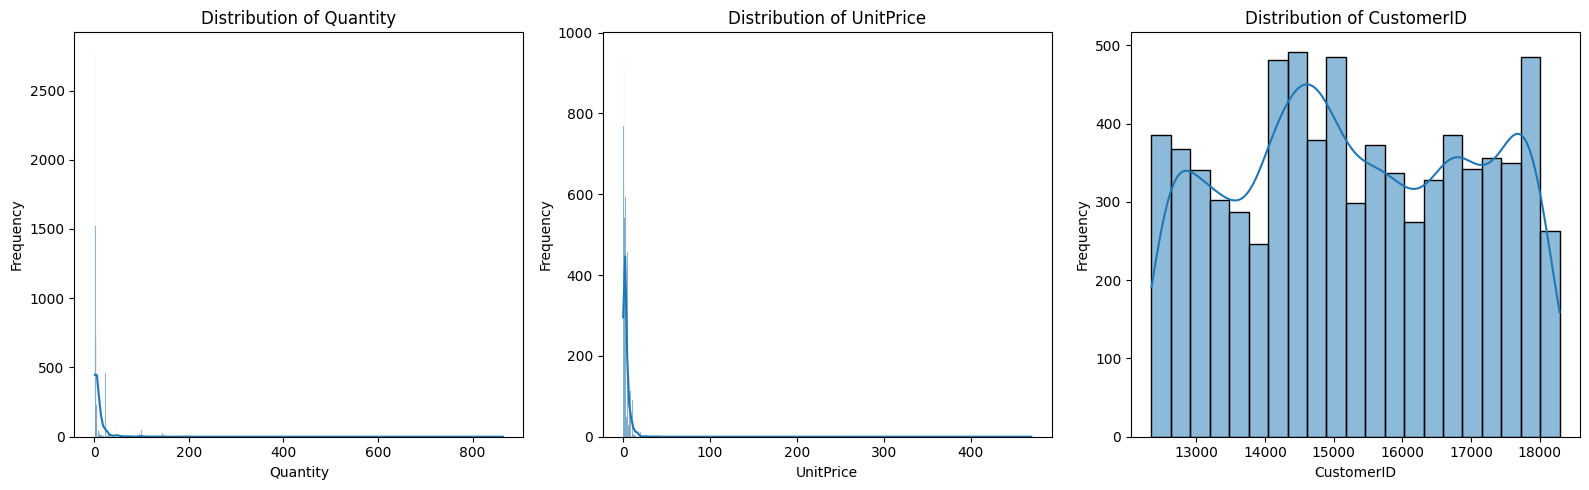

In [63]:
numeric_features = ['Quantity', 'UnitPrice', 'CustomerID']

# Use a sample for faster visualization
eda_sample = df_clean[numeric_features].sample(
    n=min(10000, len(df_clean)),
    random_state=SEED
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, numeric_features):
    sns.histplot(
        eda_sample[feature].dropna(),
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Country Distribution

The distribution of transactions across countries is examined to identify the most frequently represented countries in the dataset.

Only the top 10 countries by transaction count are displayed to keep the visualization readable.

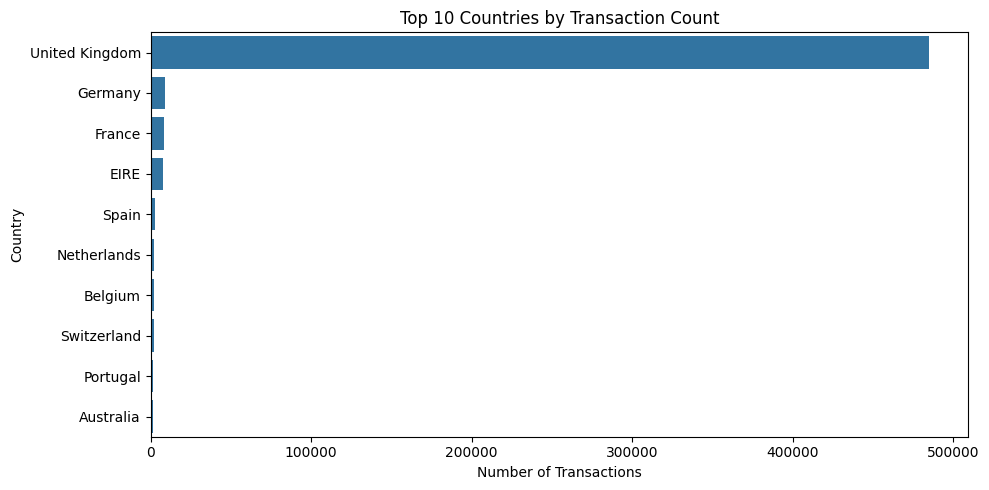

In [64]:
country_counts = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Invoice Date vs. Unit Price

The scatter plot examines whether Unit Price shows any visible variation over time.

A sample of up to 10,000 observations is used because the dataset contains a large number of transactions.

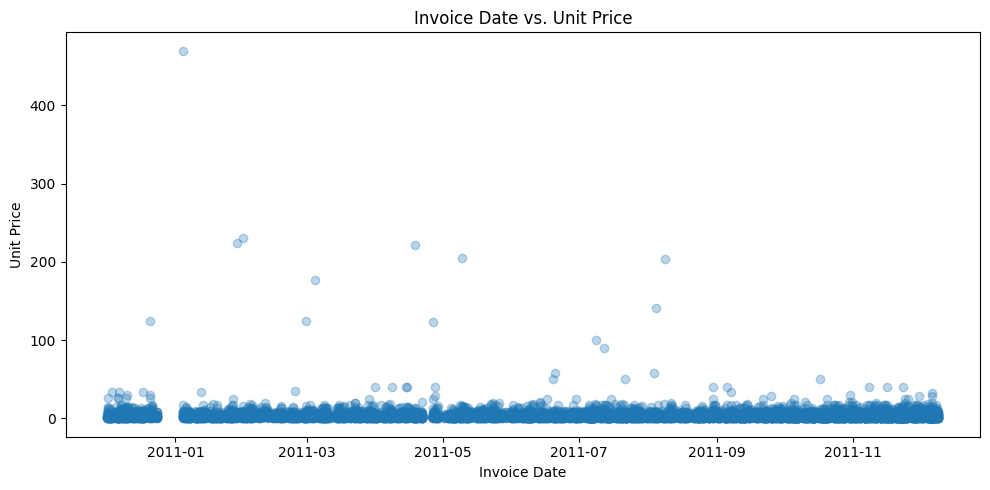

In [65]:
sample_df = df_clean.sample(
    n=min(10000, len(df_clean)),
    random_state=SEED
)

plt.figure(figsize=(10, 5))

plt.scatter(
    sample_df['InvoiceDate'],
    sample_df['UnitPrice'],
    alpha=0.3
)

plt.title("Invoice Date vs. Unit Price")
plt.xlabel("Invoice Date")
plt.ylabel("Unit Price")

plt.tight_layout()
plt.show()

### EDA Observations

* **UnitPrice:** Highly right-skewed, so `log1p` transformation may be useful.
* **Quantity:** Mostly small values with a few very large transactions, showing positive skewness.
* **CustomerID:** An identifier, not a meaningful numerical feature, so it should be handled carefully.
* **Country:** Transactions are concentrated in a few countries; rare categories should be grouped.
* **Correlation:** Quantity and UnitPrice have weak linear correlation.
* **Scatter Plots:** UnitPrice remains mostly low across Quantity and time, with a few high-price outliers.

**Overall:** UnitPrice is highly skewed and not strongly explained by the available features, motivating preprocessing, feature engineering, and target transformation.


## Section B. Data Preprocessing

This section prepares the cleaned transaction-level data for machine learning.

The preprocessing steps include missing-value handling, duplicate removal, validity checks, date-based feature engineering, feature-target separation, stratified train-test splitting, categorical encoding, and numerical scaling.

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

SEED = 42
TARGET = 'UnitPrice'

### B1. Dataset Overview

The cleaned transaction-level dataset from Section A is used for preprocessing. The dataset shape and available columns are checked before further processing.

In [67]:
print("=" * 60)
print("INITIAL DATASET")
print("=" * 60)

print("Dataset shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

INITIAL DATASET
Dataset shape: (530104, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Missing Value Analysis

Missing values are examined before model training. Missing product descriptions are replaced with `UNKNOWN_PRODUCT`. `CustomerID` is not required for the model and will be removed later.

In [68]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

print(df_clean.isnull().sum())

MISSING VALUE ANALYSIS
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64


### Handling Missing Product Descriptions

Missing values in `Description` are replaced with `UNKNOWN_PRODUCT`. This preserves the transaction records while providing a meaningful category for missing descriptions.

The `CustomerID` column will be removed later because it is an identifier rather than a useful predictive feature for this model.

In [69]:
if 'Description' in df_clean.columns:
    df_clean['Description'] = df_clean['Description'].fillna(
        'UNKNOWN_PRODUCT'
    )

print("Missing Description values after handling:",
      df_clean['Description'].isnull().sum())

Missing Description values after handling: 0


### Duplicate Handling

Duplicate rows are identified and removed to prevent repeated transaction records from influencing model training.

In [70]:
# Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df_clean.shape)

Duplicate rows found: 5226
Shape after duplicate removal: (524878, 8)


### Invalid Value and Physical Anomaly Handling

Transactions with non-positive `Quantity` or `UnitPrice` are removed because the prediction task considers valid sales transactions with positive quantity and price.

In [71]:
initial_rows = len(df_clean)

df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].reset_index(drop=True)

removed_rows = initial_rows - len(df_clean)

print("Invalid records removed:", removed_rows)
print("Shape after validity filtering:", df_clean.shape)

Invalid records removed: 0
Shape after validity filtering: (524878, 8)


### Date Validation

`InvoiceDate` is converted into datetime format so that temporal information such as year, month, day of week, and hour can be extracted reliably.

In [72]:
df_clean['InvoiceDate'] = pd.to_datetime(
    df_clean['InvoiceDate'],
    errors='coerce'
)

invalid_dates = df_clean['InvoiceDate'].isna().sum()

print("Invalid InvoiceDate values:", invalid_dates)

Invalid InvoiceDate values: 0


In [73]:
df_clean = df_clean.dropna(
    subset=['InvoiceDate']
).reset_index(drop=True)

print("Shape after date cleaning:", df_clean.shape)

Shape after date cleaning: (524878, 8)


### Outlier Analysis and Treatment

The IQR method was used to identify potential outliers in `UnitPrice`. 
The analysis identified observations beyond the IQR bounds.

These observations were retained because high UnitPrice values may represent legitimate transactions rather than data-entry errors. Instead of removing these observations, a `log1p` transformation is applied to the target variable before model training. This reduces the effect of the highly skewed target distribution while preserving the original transactions.

In [74]:
Q1 = df_clean[TARGET].quantile(0.25)
Q3 = df_clean[TARGET].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df_clean[TARGET] < lower_bound) |
    (df_clean[TARGET] > upper_bound)
)

outlier_count = outlier_mask.sum()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of UnitPrice outliers:", outlier_count)

Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower bound: -3.0700000000000003
Upper bound: 8.45
Number of UnitPrice outliers: 37827


### Feature Engineering

Temporal features are extracted from `InvoiceDate` to capture possible time-based patterns in transaction prices.

The following features are created:

- `year`: captures changes in pricing patterns across years.
- `month`: captures possible monthly or seasonal pricing patterns.
- `day_of_week`: captures differences in transaction patterns across weekdays.
- `hour`: captures possible variation in prices across different times of the day.

These engineered features provide the regression models with additional temporal information that is not directly available from the original datetime column.

In [75]:
df_clean['year'] = df_clean['InvoiceDate'].dt.year
df_clean['month'] = df_clean['InvoiceDate'].dt.month
df_clean['day_of_week'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['hour'] = df_clean['InvoiceDate'].dt.hour

print("Created features:")
print("- year")
print("- month")
print("- day_of_week")
print("- hour")

Created features:
- year
- month
- day_of_week
- hour


### Removing Identifier and High-Cardinality Columns

Columns such as `InvoiceNo`, `StockCode`, `CustomerID`, and the original `InvoiceDate` are removed because they are identifiers or have high cardinality.

`Description` is also removed to avoid creating a very large categorical feature space.

The extracted temporal features are retained for modeling.

In [76]:
df_clean = df_clean.drop(
    columns=[
        'InvoiceDate',
        'InvoiceNo',
        'StockCode',
        'Description',
        'CustomerID'
    ],
    errors='ignore'
)

print("Remaining columns:")
print(df_clean.columns.tolist())

Remaining columns:
['Quantity', 'UnitPrice', 'Country', 'year', 'month', 'day_of_week', 'hour']


### Separate Features and Target

`UnitPrice` is used as the regression target.

The original target values are preserved for final evaluation, while a logarithmic transformation is applied to the target to reduce the effect of its right-skewed distribution.

In [77]:
X = df_clean.drop(columns=[TARGET])

y_original = df_clean[TARGET].copy()

y = np.log1p(y_original)

print("Number of features:", X.shape[1])
print("Target:", TARGET)

Number of features: 6
Target: UnitPrice


### Final Feature Selection

For regression modelling, relevant transaction and temporal features are selected.

`CustomerID` is excluded because it is an identifier and its numerical value does not represent a meaningful quantitative relationship with `UnitPrice`.

`InvoiceNo`, `StockCode`, and `Description` are also excluded because they are identifiers or high-cardinality text fields that are not directly suitable for the current regression models.

The selected features are:

- `Quantity`
- `year`
- `month`
- `day_of_week`
- `hour`
- `Country`

`UnitPrice` is retained separately as the regression target.

In [78]:
# Select features for regression
FEATURES = [
    'Quantity',
    'year',
    'month',
    'day_of_week',
    'hour',
    'Country'
]

TARGET = 'UnitPrice'

X = df_clean[FEATURES].copy()
y_original = df_clean[TARGET].copy()

# Log-transform the target to reduce strong right-skew
y = np.log1p(y_original)

print("Selected features:")
print(FEATURES)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['Quantity', 'year', 'month', 'day_of_week', 'hour', 'Country']

Feature matrix shape: (524878, 6)
Target shape: (524878,)


### Stratified Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Since `UnitPrice` is a continuous regression target, quantile-based bins are created to approximately preserve the target distribution in both the training and testing sets.

A fixed random seed of 42 is used to ensure reproducibility.

In [26]:
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

In [27]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    y_train_original,
    y_test_original
) = train_test_split(
    X,
    y,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bins
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

TRAIN / TEST SPLIT
X_train shape: (419902, 6)
X_test shape : (104976, 6)
y_train shape: (419902,)
y_test shape : (104976,)


### Rare Category Handling

Rare countries are grouped into an `Other` category to reduce the effect of very infrequent categories.

Country frequencies are calculated using only the training data, and the same grouping is applied to the test data. This prevents information from the test set from influencing preprocessing.

In [28]:
if 'Country' in X_train.columns:

    country_counts = X_train['Country'].value_counts()

    rare_countries = country_counts[
        country_counts < 5
    ].index

    X_train['Country'] = X_train['Country'].replace(
        rare_countries,
        'Other'
    )

    X_test['Country'] = X_test['Country'].replace(
        rare_countries,
        'Other'
    )

    print("Rare countries grouped:", len(rare_countries))

Rare countries grouped: 0


### Identify Numerical and Categorical Features

The features are separated into numerical and categorical groups.

Numerical features will be standardized using `StandardScaler`, while categorical features will be converted into numerical form using one-hot encoding.

In [29]:
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Numerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

Numerical features:
['Quantity', 'year', 'month', 'day_of_week', 'hour']

Categorical features:
['Country']


### Scaling and Encoding

A `ColumnTransformer` is used to apply different preprocessing methods to numerical and categorical features.

- Numerical features are standardized using `StandardScaler`.
- The `Country` feature is converted into numerical form using one-hot encoding.
- The first category is dropped to avoid redundant dummy variables.
- Unknown categories are ignored safely during transformation.

The preprocessing transformer is fitted only on the training data and then applied to the test data.

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numerical and categorical features
numeric_features = [
    'Quantity',
    'year',
    'month',
    'day_of_week',
    'hour'
]

categorical_features = ['Country']

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Quantity', 'year', 'month', 'day_of_week', 'hour']
Categorical features: ['Country']


In [84]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### Fit Preprocessing on Training Data Only

The scaler and encoder are fitted only on the training data.

The test data is transformed using the already-fitted preprocessing objects. This prevents information from the test set from influencing the training process.

In [85]:
# Fit the preprocessor using training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape :", X_test_processed.shape)

Processed training data shape: (419902, 42)
Processed testing data shape : (104976, 42)


In [86]:
# Verify that preprocessing produced valid numerical data
print("Training data contains NaN:", np.isnan(X_train_processed).any())
print("Testing data contains NaN :", np.isnan(X_test_processed).any())

Training data contains NaN: False
Testing data contains NaN : False


### Final Processed Feature Matrices

The transformed numerical arrays are converted back into DataFrames with the generated feature names.

These processed matrices will be used as inputs for the regression models in Section C.

In [87]:
feature_names = preprocessor.get_feature_names_out()

X_train_scaled = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data shape:", X_train_scaled.shape)
print("Processed testing data shape:", X_test_scaled.shape)

Processed training data shape: (419902, 42)
Processed testing data shape: (104976, 42)


### Final Preprocessing Validation

The final preprocessing stage is validated by checking the processed dataset dimensions and confirming that no missing values remain in the training or testing feature matrices.

In [88]:
print("=" * 60)
print("FINAL PREPROCESSING VALIDATION")
print("=" * 60)

print("Processed X_train shape:", X_train_scaled.shape)
print("Processed X_test shape :", X_test_scaled.shape)

print("\nMissing values in X_train:")
print(X_train_scaled.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test_scaled.isnull().sum().sum())

FINAL PREPROCESSING VALIDATION
Processed X_train shape: (419902, 42)
Processed X_test shape : (104976, 42)

Missing values in X_train:
0

Missing values in X_test:
0


### Target Transformation Validation

The original and log-transformed target distributions are compared using summary statistics to verify the effect of the logarithmic transformation.

In [89]:
print("\nTarget transformation:")
print("Original target mean:", y_original.mean())
print("Original target median:", y_original.median())
print("Log-transformed target mean:", y.mean())


Target transformation:
Original target mean: 3.9225725673394587
Original target median: 2.08
Log-transformed target mean: 1.241809610993718


In [90]:
print("\nSection B preprocessing completed successfully.")

print("Processed Features Head:")
print(X_train_scaled.head())


Section B preprocessing completed successfully.
Processed Features Head:
        num__Quantity  num__year  num__month  num__day_of_week  num__hour  \
434628      -0.044564   0.290862    0.982674         -0.774009  -0.030348   
129063      -0.050314   0.290862   -1.297470          0.850930  -0.849162   
235692      -0.050314   0.290862   -0.442416         -0.232362   0.788466   
515158      -0.056065   0.290862    1.267692         -0.774009   1.197874   
21830       -0.056065  -3.438061    1.267692          0.850930  -1.667977   

        cat__Country_Austria  cat__Country_Bahrain  cat__Country_Belgium  \
434628                   0.0                   0.0                   0.0   
129063                   0.0                   0.0                   0.0   
235692                   0.0                   0.0                   0.0   
515158                   0.0                   0.0                   0.0   
21830                    0.0                   0.0                   0.0   

      

# Section C. Regression Track

The regression models are trained to predict `UnitPrice` at the individual transaction level.

The first five required regression algorithms are evaluated using the same training data and the same held-out test set.

The target was log-transformed during preprocessing, so predictions are converted back to the original `UnitPrice` scale before calculating the evaluation metrics.

## Regression Model Imports

The required regression algorithms and evaluation metrics are imported for model training and comparison.

In [92]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

### Training and Testing Data

All regression algorithms use the same preprocessed training and testing datasets to ensure a fair comparison between models.

In [93]:
print("=" * 70)
print("VERSION 2 (TRANSACTION LEVEL)")
print("FIRST 5 REGRESSION ALGORITHMS")
print("=" * 70)

print("\nTraining rows:", X_train_scaled.shape[0])
print("Testing rows :", X_test_scaled.shape[0])

VERSION 2 (TRANSACTION LEVEL)
FIRST 5 REGRESSION ALGORITHMS

Training rows: 419902
Testing rows : 104976


## Define the First Five Regression Algorithms

The first five required regression algorithms are implemented:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression

The same preprocessed features are provided to each model.

In [ ]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=0.01,
        max_iter=10000
    ),

    "ElasticNet Regression": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000
    ),

    "Polynomial Regression": Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])
}

## Training the Linear and Regularized Regression Models

The Linear Regression, Ridge, Lasso, and ElasticNet models are trained using the same preprocessed training data.

All models are evaluated on the same held-out test set using R², RMSE, and MAE to ensure a fair comparison.

In [97]:
regression_results = []
trained_models = {}

for name in [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression"
]:
    model = models[name]

    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    regression_results.append({
        "Model": name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = model

results_df = pd.DataFrame(regression_results)

print(results_df)

                   Model        R²      RMSE       MAE
0      Linear Regression  0.009373  0.641620  0.502738
1       Ridge Regression  0.009380  0.641618  0.502737
2       Lasso Regression  0.006389  0.642586  0.503993
3  ElasticNet Regression  0.007678  0.642169  0.503563


## Regression Model Evaluation

The models are evaluated on the original `UnitPrice` scale using three required regression metrics:

- R²
- RMSE
- MAE

Higher R² indicates better explanatory performance, while lower RMSE and MAE indicate smaller prediction errors.

In [39]:
results = []

for name in models.keys():

    y_pred_original = predictions[name]

    r2 = r2_score(
        y_test_original,
        y_pred_original
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            y_pred_original
        )
    )

    mae = mean_absolute_error(
        y_test_original,
        y_pred_original
    )

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

### Model Comparison Table

The evaluation results are combined into a single table and ranked according to R², as required by the project guidelines.

In [40]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_df.insert(
    0,
    "Rank",
    range(1, len(comparison_df) + 1)
)

### Regression Performance Comparison

The following table presents the performance of the first five regression algorithms on the same held-out test set.

In [41]:
print("=" * 70)
print("C2 - VERSION 2 (TRANSACTION LEVEL)")
print("FIRST 5 REGRESSION MODEL COMPARISON")
print("=" * 70)

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "R2": "{:.4f}".format,
            "RMSE": "{:.4f}".format,
            "MAE": "{:.4f}".format
        }
    )
)

C2 - VERSION 2 (TRANSACTION LEVEL)
FIRST 5 REGRESSION MODEL COMPARISON
 Rank                 Model      R2    RMSE    MAE
    1 Polynomial Regression -0.0011 35.1202 2.7264
    2     Linear Regression -0.0016 35.1292 2.7644
    3      Ridge Regression -0.0016 35.1293 2.7644
    4 ElasticNet Regression -0.0017 35.1304 2.7670
    5      Lasso Regression -0.0017 35.1307 2.7684


## Best Model Among the First Five Algorithms

The model with the highest R² is selected as the best-performing model among the first five regression algorithms.

In [42]:
best_model_name = comparison_df.iloc[0]["Model"]

best_r2 = comparison_df.iloc[0]["R2"]
best_rmse = comparison_df.iloc[0]["RMSE"]
best_mae = comparison_df.iloc[0]["MAE"]

print("Best model:", best_model_name)
print("R2        :", round(best_r2, 4))
print("RMSE      :", round(best_rmse, 4))
print("MAE       :", round(best_mae, 4))

Best model: Polynomial Regression
R2        : -0.0011
RMSE      : 35.1202
MAE       : 2.7264


### Performance Interpretation

The best-performing model is identified based on R². Its RMSE and MAE are also reported to provide additional information about prediction error on the original UnitPrice scale.

In [43]:
print(
    f"{best_model_name} achieved the highest R2 of "
    f"{best_r2:.4f} among the first five regression algorithms."
)

print(
    f"The model has an RMSE of {best_rmse:.4f} "
    f"and an MAE of {best_mae:.4f} "
    f"on the original UnitPrice scale."
)

print(
    "\nHigher R2 indicates better explanatory performance, "
    "while lower RMSE and MAE indicate smaller prediction errors."
)

Polynomial Regression achieved the highest R2 of -0.0011 among the first five regression algorithms.
The model has an RMSE of 35.1202 and an MAE of 2.7264 on the original UnitPrice scale.

Higher R2 indicates better explanatory performance, while lower RMSE and MAE indicate smaller prediction errors.
